<a href="https://colab.research.google.com/github/bhuvanarangaiah/03MAIR-Algoritmos-de-Optimizacion-2026/blob/main/03MIAR_David%C3%81lvarezRobles_AG4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03MIAR - Algoritmos de optimización
## Actividad guiada 4

*David Álvarez Robles*

## Presentación

Profesor:
- Grupos A2, A3, B1, B2: David Álvarez Robles (dalvarezr@professor.universidadviu.com)

## Objetivos
- Implementar y comprender el funcionamiento del algoritmo de optimización basado en colonia de hormigas (ACO)
- Implementar y comprender el funcionamiento de algoritmos genéticos para la búsqueda de soluciones

## Librerías y simulación del problema del agente viajero en Python
- Uso de librería tsplib95
- Visualización de datos

In [ ]:
!pip install tsplib95
import tsplib95
import random
from math import e
import math
import copy
import urllib.request

In [ ]:
# Descargamos el fichero de datos (Matriz de distancias)
file = "swiss42.tsp" ;
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x7fd0cab22900>)

In [ ]:
problema = tsplib95.load(file)
nodos = list(problema.get_nodes())
aristas = list(problema.get_edges())

#print(problema) # Descripción estándar
#print(nodos) # Nodos 0, 1, 2 ... 42
#print(aristas) # Ver https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

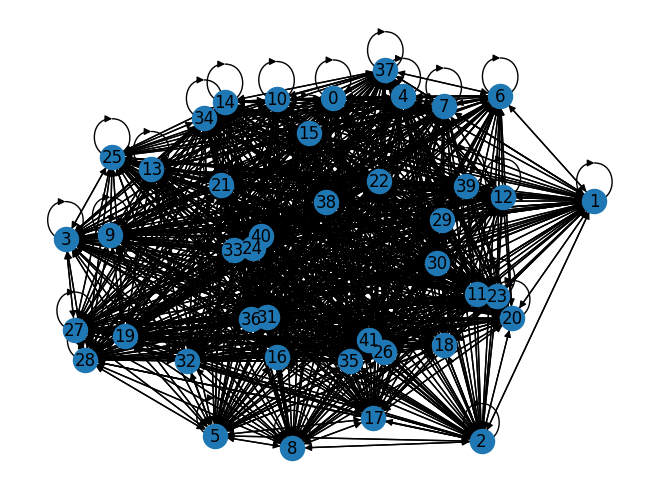

In [ ]:
# Probamos algunas funciones del objeto problema, que ya nos vienen dadas

# Distancia entre nodos (ciudades)
problema.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
#dir(problema)

import networkx as nx
import matplotlib.pyplot as plt
nx.draw(problema.get_graph(), with_labels=True, arrows=True)
plt.show()

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()

## Funciones básicas para algoritmos de búsqueda

In [ ]:
# Genera una solución aleatoria con comienzo en en el nodo 0
def crear_solucion(nodos):
    # Nodo inicial = 0
    solucion = [nodos[0]]
    # Para el resto de nodos, los recorremos e incluimos aleatoriamente en la solución cada uno de ellos
    for n in nodos[1:]:
        # Debemos quitar el nodo 0 y los ya incluidos en cada iteración
        solucion = solucion + [random.choice(list(set(nodos) - set({nodos[0]}) - set(solucion)))]
    return solucion


# Devuelve la distancia entre dos nodos aprovechando la función get_weight() de tsplib95
def distancia(a,b, problema):
    return problema.get_weight(a,b)


# Devuelve la distancia total de una trayectoria/solución
def distancia_total(solucion, problema):
    distancia_total = 0
    # Para cada nodo de la solución calculamos su distancia a siguiente nodo
    for i in range(len(solucion)-1):
        distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problema)
    # Devolvemos la distancia total más la distancia del último nodo al primero para cerrar viaje
    return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problema)


solucion = crear_solucion(nodos)
print(solucion)
print(distancia_total(solucion, problema))

[0, 38, 6, 39, 31, 25, 12, 29, 8, 21, 10, 20, 30, 35, 3, 19, 27, 23, 13, 16, 9, 37, 32, 33, 22, 40, 28, 5, 14, 34, 41, 15, 18, 36, 11, 7, 4, 26, 24, 1, 2, 17]
5066


## Optimización Colonia Hormigas (ACO) - TSP
- Uso de solución constructiva basada en feromonas y evaporación
- Aquí cada agente (hormiga) construye un camino y deja feromonas de modo que otras hormigas "siguen" el rastro

In [ ]:
def anadir_nodo(hormiga, nodos):
    # Mejora: Establecer una funcion de probabilidad para
    # Añadir un nuevo nodo dependiendo de los nodos mas cercanos y de las feromonas depositadas
    # Ahora mismo solo se añade el nuevo nodo de manera aleatoria
    return random.choice(list(set(range(1,len(nodos))) - set(hormiga)))


def incrementar_feromona(problema, T, hormiga) :
    # Incrementa segun la calidad de la solución. Añadir una cantidad inversamente proporcional a la distancia total
    for i in range(len(hormiga)-1):
        T[hormiga[i]][hormiga[i+1]] += 1000/distancia_total(hormiga, problema)
    return T


def evaporar_feromonas(T, nodos):
    # Evapora 0.3 el valor de la feromona, sin que baje de 1
    # Mejora:Podemos elegir diferentes funciones de evaporación dependiendo de la cantidad actual y de la suma total de feromonas depositadas,...
    T = [[ max(T[i][j] - 0.3, 1) for j in range(len(nodos)) ] for i in range(len(nodos))]
    return T

La mejor solución encontrada es: [0, 40, 24, 28, 11, 7, 36, 17, 19, 20, 39, 34, 41, 10, 29, 22, 32, 2, 16, 6, 14, 13, 12, 18, 25, 8, 23, 21, 4, 5, 27, 35, 33, 31, 30, 1, 38, 9, 15, 37, 3, 26] con 5000 hormigas
Distancia: 3788


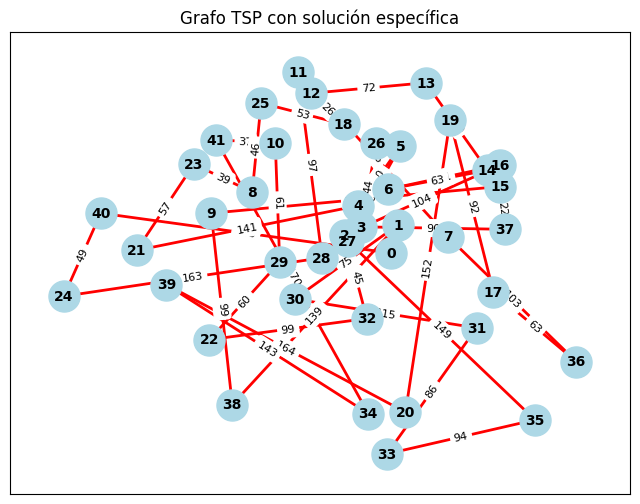

In [ ]:
def aco(problema, n_hormigas):
    nodos = list(problema.get_nodes())
    aristas = list(problema.get_edges())

    # Inicializa la matriz de feromonas por cada arista (ruta entre ciudades NxN) con una cantidad inicial de feromonas por arista de 1
    # Mejora: inicializar con valores diferentes dependiendo diferentes criterios
    T = [[ 1 for _ in range(len(nodos)) ] for _ in range(len(nodos))]

    # Se generan los agentes (hormigas) que serán estructuras de caminos desde 0
    hormigas = [[0] for _ in range(n_hormigas)]

    # Recorre cada agente construyendo la solución
    for hormiga in range(n_hormigas) :
        # Para cada agente se construye un camino
        for i in range(len(nodos)-1) :
            # Elige el siguiente nodo
            nuevo_nodo = anadir_nodo(hormigas[hormiga], nodos)
            hormigas[hormiga].append(nuevo_nodo)

        # Incrementa feromonas en base a la solución
        T = incrementar_feromona(problema, T, hormigas[hormiga])
        #print("Feromonas(1)", T)

        # Evapora feromonas
        T = evaporar_feromonas(T, nodos)
        #print("Feromonas(2)", T)

    #Seleccionamos el mejor agente
    mejor_solucion = []
    mejor_distancia = 10e100

    i=1

    for hormiga in range(n_hormigas):
        distancia_actual = distancia_total(hormigas[hormiga], problema)

        #print(f"Hormiga: {i} // Distancia actual: {distancia_actual}\n")
        i+=1

        if distancia_actual < mejor_distancia:
            mejor_solucion = hormigas[hormiga]
            mejor_distancia =distancia_actual

    return mejor_solucion, mejor_distancia



n_hormigas = 5000
mejor_solucion, mejor_distancia  = aco(problema, n_hormigas)

print(f"La mejor solución encontrada es: {mejor_solucion} con {n_hormigas} hormigas")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

## Optimización Colonia Hormigas (ACO) mejorado - TSP
- Uso de solución constructiva basada en feromonas y evaporación
- Aquí cada agente (hormiga) construye un camino y deja feromonas de modo que otras hormigas "siguen" el rastro
- Las feromonas importan a la hora de elegir siguiente nodo

In [ ]:
def anadir_nodo(hormiga, nodos, T, problema, alpha=1, beta=2):
    candidatos = list(set(range(1, len(nodos))) - set(hormiga))
    i = hormiga[-1]  # nodo actual

    probabilidades = []

    for j in candidatos:
        # feromona
        tau = T[i][j]

        # heurística (inverso de distancia)
        dist = distancia(i, j, problema)
        eta = 1 / (dist + 1e-6)

        valor = (tau ** alpha) * (eta ** beta)
        probabilidades.append(valor)

    # normalización
    suma = sum(probabilidades)
    probabilidades = [p / suma for p in probabilidades]

    # selección probabilística
    return random.choices(candidatos, weights=probabilidades, k=1)[0]


def incrementar_feromona(problema, T, hormiga) :
    # Incrementa segun la calidad de la solución. Añadir una cantidad inversamente proporcional a la distancia total
    for i in range(len(hormiga)-1):
        T[hormiga[i]][hormiga[i+1]] += 1000/distancia_total(hormiga, problema)
    return T


def evaporar_feromonas(T, nodos):
    # Evapora 0.3 el valor de la feromona, sin que baje de 1
    # Mejora:Podemos elegir diferentes funciones de evaporación dependiendo de la cantidad actual y de la suma total de feromonas depositadas,...
    T = [[ max(T[i][j] - 0.3, 1) for j in range(len(nodos)) ] for i in range(len(nodos))]
    return T

La mejor solución encontrada es: [0, 1, 3, 4, 27, 2, 29, 9, 41, 23, 40, 24, 21, 8, 10, 25, 11, 12, 18, 26, 5, 19, 14, 16, 15, 37, 13, 6, 34, 32, 33, 20, 17, 36, 35, 31, 7, 28, 30, 38, 22, 39] con 5000 hormigas
Distancia: 1825


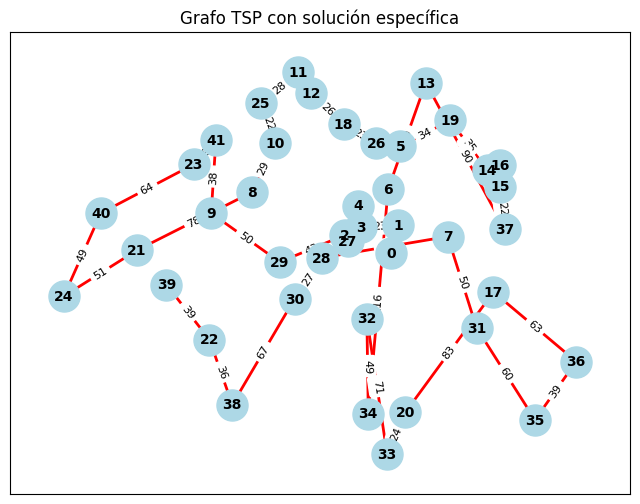

In [ ]:
def aco(problema, n_hormigas):
    nodos = list(problema.get_nodes())
    aristas = list(problema.get_edges())

    # Inicializa la matriz de feromonas con una cantidad inicial de feromonas por arista de 1
    # Mejora: inicializar con valores diferentes dependiendo diferentes criterios
    T = [[ 1 for _ in range(len(nodos)) ] for _ in range(len(nodos))]

    # Se generan los agentes (hormigas) que serán estructuras de caminos desde 0
    hormigas = [[0] for _ in range(n_hormigas)]

    # Recorre cada agente construyendo la solución
    for hormiga in range(n_hormigas) :
        # Para cada agente se construye un camino
        for i in range(len(nodos)-1) :
            # Elige el siguiente nodo
            nuevo_nodo = anadir_nodo(hormigas[hormiga], nodos, T, problema)
            hormigas[hormiga].append(nuevo_nodo)

        # Incrementa feromonas en base a la solución
        T = incrementar_feromona(problema, T, hormigas[hormiga])
        #print("Feromonas(1)", T)

        # Evapora feromonas
        T = evaporar_feromonas(T, nodos)
        #print("Feromonas(2)", T)

    #Seleccionamos el mejor agente
    mejor_solucion = []
    mejor_distancia = 10e100

    i=1

    for hormiga in range(n_hormigas):
        distancia_actual = distancia_total(hormigas[hormiga], problema)

        #print(f"Hormiga: {i} // Distancia actual: {distancia_actual}\n")
        i+=1

        if distancia_actual < mejor_distancia:
            mejor_solucion = hormigas[hormiga]
            mejor_distancia =distancia_actual

    return mejor_solucion, mejor_distancia



n_hormigas = 5000
mejor_solucion, mejor_distancia  = aco(problema, n_hormigas)

print(f"La mejor solución encontrada es: {mejor_solucion} con {n_hormigas} hormigas")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

# Algoritmo ACO más preciso
* Mejoras como evaporación por generación, evaporación proporcional...


La mejor solución encontrada es: [0, 1, 6, 4, 3, 27, 2, 28, 29, 30, 38, 22, 39, 21, 40, 24, 41, 23, 9, 8, 10, 25, 11, 12, 18, 26, 5, 13, 19, 14, 15, 16, 37, 17, 31, 36, 35, 20, 33, 34, 32, 7]
Distancia: 1338.00


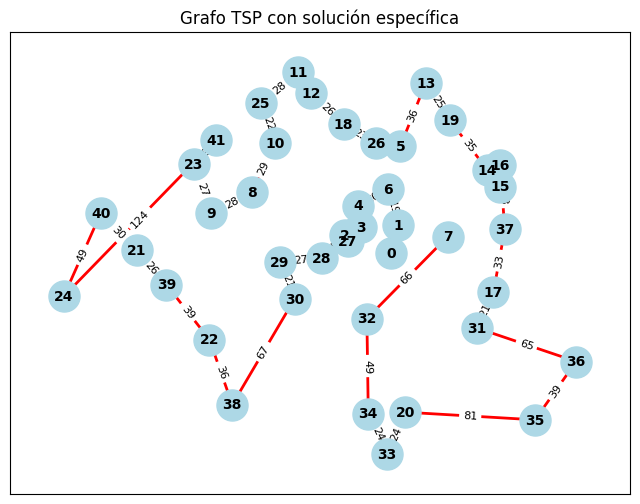

In [ ]:
import random

# ---------------------------------------------------------------------------
# Construcción de solución para una hormiga
# ---------------------------------------------------------------------------

def anadir_nodo(hormiga, nodos, T, problema, alpha=1, beta=2):
    candidatos = list(set(range(1, len(nodos))) - set(hormiga))
    i = hormiga[-1]  # nodo actual

    probabilidades = []
    for j in candidatos:
        tau = T[i][j]
        dist = distancia(i, j, problema)
        eta = 1 / (dist + 1e-6)
        valor = (tau ** alpha) * (eta ** beta)
        probabilidades.append(valor)

    suma = sum(probabilidades)
    probabilidades = [p / suma for p in probabilidades]

    return random.choices(candidatos, weights=probabilidades, k=1)[0]


# ---------------------------------------------------------------------------
# Actualización de feromonas
# ---------------------------------------------------------------------------

def incrementar_feromona(problema, T, hormiga, Q=1000):
    """
    Incrementa feromona según la calidad de la solución (proporcional a 1/distancia_total).
    Se actualiza simétricamente T[i][j] y T[j][i], ya que el grafo es no dirigido.
    Se cierra el ciclo (última arista de vuelta al nodo de origen), asumiendo
         que distancia_total() también contempla esa arista de cierre.
    """
    aporte = Q / distancia_total(hormiga, problema)

    for i in range(len(hormiga) - 1):
        a, b = hormiga[i], hormiga[i + 1]
        T[a][b] += aporte
        T[b][a] += aporte

    # Cierre del ciclo TSP: última ciudad -> ciudad de origen
    a, b = hormiga[-1], hormiga[0]
    T[a][b] += aporte
    T[b][a] += aporte

    return T


def evaporar_feromonas(T, nodos, rho=0.3, minimo=0.01):
    """
    Evaporación multiplicativa clásica: T = (1 - rho) * T
    Se sustituye la resta fija + suelo alto (1) por un decaimiento
         multiplicativo con un suelo pequeño, más apropiado para esta escala.
    """
    n = len(nodos)
    return [[max((1 - rho) * T[i][j], minimo) for j in range(n)] for i in range(n)]


# ---------------------------------------------------------------------------
# Algoritmo ACO por generaciones
# ---------------------------------------------------------------------------

def aco(problema, n_hormigas_por_generacion, n_generaciones, rho=0.3, Q=1000, alpha=1, beta=2):
    nodos = list(problema.get_nodes())
    n = len(nodos)

    # Inicializa la matriz de feromonas
    T = [[1 for _ in range(n)] for _ in range(n)]

    mejor_solucion_global = []
    mejor_distancia_global = 10e100
    historico_mejor = []  # para poder graficar la convergencia

    for gen in range(n_generaciones):
        hormigas = [[0] for _ in range(n_hormigas_por_generacion)]

        # Todas las hormigas de esta generación construyen su camino
        # usando la MISMA matriz T (no se modifica hasta el final de la generación)
        for h in range(n_hormigas_por_generacion):
            for _ in range(n - 1):
                nuevo_nodo = anadir_nodo(hormigas[h], nodos, T, problema, alpha, beta)
                hormigas[h].append(nuevo_nodo)

        # Se depositan feromonas de TODAS las hormigas de la generación
        for h in hormigas:
            T = incrementar_feromona(problema, T, h, Q=Q)

        # Evaporación: una única vez por generación (no por hormiga)
        T = evaporar_feromonas(T, nodos, rho=rho)

        # Evaluamos la generación
        mejor_distancia_gen = 10e100
        mejor_hormiga_gen = []
        for h in hormigas:
            d = distancia_total(h, problema)
            if d < mejor_distancia_gen:
                mejor_distancia_gen = d
                mejor_hormiga_gen = h

        if mejor_distancia_gen < mejor_distancia_global:
            mejor_distancia_global = mejor_distancia_gen
            mejor_solucion_global = mejor_hormiga_gen

        historico_mejor.append(mejor_distancia_global)
        #print(f"Generación {gen+1}/{n_generaciones} // "
              #f"Mejor de la generación: {mejor_distancia_gen:.2f} // "
              #f"Mejor global: {mejor_distancia_global:.2f}")

    return mejor_solucion_global, mejor_distancia_global, historico_mejor


# ---------------------------------------------------------------------------
# Ejecución
# ---------------------------------------------------------------------------

n_hormigas_por_generacion = 50
n_generaciones = 100

mejor_solucion, mejor_distancia, historico = aco(
    problema,
    n_hormigas_por_generacion=n_hormigas_por_generacion,
    n_generaciones=n_generaciones,
    rho=0.3,
    Q=1000,
)

print(f"\nLa mejor solución encontrada es: {mejor_solucion}")
print(f"Distancia: {mejor_distancia:.2f}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)

#import matplotlib.pyplot as plt
#plt.plot(historico)
#plt.xlabel("Generación")
#plt.ylabel("Mejor distancia global")
#plt.title("Convergencia ACO - swiss42")
#plt.show()

## Algoritmos genéticos y evolutivos - TSP
- Se comienza con una población inicial y se van aplicando criterios incluyendo selección, cruzamiento, mutación y factibilidad entre otros para resolver el problema
- Se realizan una serie de iteraciones que permiten ir "mejorando la especie" hasta converger a soluciones mejores
- Hay un componente probabilista importante y que se puede modificar con hiperparámetros

In [ ]:
# Genera una población inicial de soluciones de tamaño tamano_poblacion.
# Puede ser válida la solución aleatoria de la AG3: crear_solucion(nodos)
def generar_poblacion(nodos,tamano_poblacion):
    return [crear_solucion(nodos) for _ in range(tamano_poblacion)]

In [ ]:
# Evalúa la población y devuelve el mejor individuo
def evaluar_poblacion(poblacion, problema):
    mejor_solucion = []
    mejor_distancia = float("inf")

    for p in poblacion:
        distancia_referencia = distancia_total(p, problema)
        if (distancia_referencia < mejor_distancia):
            mejor_solucion = p
            mejor_distancia = distancia_referencia

    return mejor_solucion, mejor_distancia

In [ ]:
# Función de cruce. Recibe una población (lista de soluciones) y devuelve la población ampliada con los hijos.
# Todos los individuos de la población son selecionados para el cruce (si la población es par)
# Podría aplicarse un proceso previo de selección para elegir los individuos que se desea cruzar.
def cruzar(poblacion, mutacion, problema):
    poblacion_copia = copy.deepcopy(poblacion)
    poblacion_final = copy.deepcopy(poblacion)

    while(len(poblacion_copia) > 1):
        padre1, padre2 = random.sample(poblacion_copia, 2)
        poblacion_copia.remove(padre1)
        poblacion_copia.remove(padre2)
        poblacion_final.extend(descendencia([padre1, padre2], problema, mutacion))

    return poblacion_final

In [ ]:
# Función para generar hijos a partir de 2 padres:
# Se elige el metodo de 1-punto de corte pero es posible usar otros n-puntos, uniforme, dependiendo del problema
def descendencia(padres, problema, mutacion):
    punto_corte = random.sample(range(1, len(padres[0])), 1)[0]

    hijo1 = padres[0][:punto_corte] + padres[1][punto_corte:]
    hijo2 = padres[1][:punto_corte] + padres[0][punto_corte:]

    hijo1 = factibilizar(hijo1, problema)
    hijo2 = factibilizar(hijo2, problema)

    mutacion1 = mutar(hijo1, mutacion)
    mutacion2 = mutar(hijo2, mutacion)

    mutacion1 = factibilizar(mutacion1, problema)
    mutacion2 = factibilizar(mutacion2, problema)


    return [hijo1, hijo2, mutacion1, mutacion1]

In [ ]:
# Para el operador de cruce 1-punto los hijos generados no son soluciones (algunos nodos se repiten y otros no están)
def factibilizar(solucion, problema):
    solucion = solucion[:]

    nodos = list(problema.get_nodes())
    nodos_desaparecidos = list(set(nodos) - set(solucion))

    usados = {}

    for i in range(len(solucion)):
        if solucion[i] in usados:
            solucion[i] = nodos_desaparecidos.pop(0)
        else:
            usados[solucion[i]] = True

    return solucion

In [ ]:
# Función de mutación. Se eligen dos nodos y se intercambia. Se podrían añadir otros operaradores
# Se hace mutaciones mutacion% de las veces
def mutar(solucion, mutacion):
    if random.random() < mutacion:
        i, j = random.sample(range(len(solucion)), 2)

        solucion = solucion[:]
        solucion[i], solucion[j] = solucion[j], solucion[i]

        return solucion

    return solucion[:]

In [ ]:
# Función de selección de la población. Recibe como parámetro una población y
# devuelve una población a la que se ha eliminado individuos poco aptos (fitness alto) y para mantener una población estable de tamano_poblacion individuos
# Se tiene en cuenta el porcentaje elitismo pasado como parámetro
# Para los individuos que no son de la élite podríamos usar una selección de ruleta (proporcional a su fitness)
def seleccionar(problema, poblacion, tamano_poblacion, elitismo):
    # Se ordena la población según el fitness (tamaño del recorrido) en una lista de elementos [distancia, solucion]
    poblacion_ordenada = sorted([ [distancia_total(solucion,problema), solucion] for solucion in poblacion ], key = lambda x:x[0])

    # Devolvemos elitismo% y el resto se eligen aleatoriamente
    return [x[1] for x in poblacion_ordenada][:int(tamano_poblacion*elitismo)] + random.sample([x[1] for x in poblacion_ordenada][int(tamano_poblacion*elitismo):] , int(tamano_poblacion*(1-elitismo)) )

Generacion # 0 
La mejor solución es: [0, 38, 1, 27, 6, 3, 16, 32, 26, 24, 8, 9, 39, 21, 10, 41, 7, 33, 34, 19, 37, 36, 4, 22, 5, 23, 40, 11, 12, 13, 2, 17, 15, 35, 20, 18, 14, 28, 30, 29, 25, 31] 
con distancia  3873 

Generacion # 1 
La mejor solución es: [0, 29, 24, 40, 22, 39, 6, 37, 4, 18, 13, 5, 16, 7, 30, 32, 41, 33, 38, 36, 26, 17, 19, 3, 15, 34, 35, 20, 2, 1, 8, 11, 10, 9, 12, 14, 21, 23, 25, 27, 28, 31] 
con distancia  3801 

Generacion # 2 
La mejor solución es: [0, 29, 24, 40, 22, 39, 6, 37, 4, 18, 13, 5, 16, 7, 32, 1, 35, 31, 36, 38, 26, 3, 8, 41, 21, 9, 10, 15, 25, 12, 14, 34, 20, 23, 17, 33, 11, 2, 27, 30, 19, 28] 
con distancia  3762 

Generacion # 3 
La mejor solución es: [0, 34, 32, 27, 18, 40, 17, 7, 24, 10, 15, 22, 20, 35, 36, 31, 33, 39, 2, 37, 6, 14, 16, 26, 1, 38, 8, 9, 23, 41, 11, 12, 5, 4, 28, 3, 19, 13, 25, 21, 29, 30] 
con distancia  3521 

Generacion # 4 
La mejor solución es: [0, 34, 32, 27, 18, 40, 17, 7, 24, 10, 15, 22, 20, 35, 36, 31, 33, 39, 2, 37, 6, 1

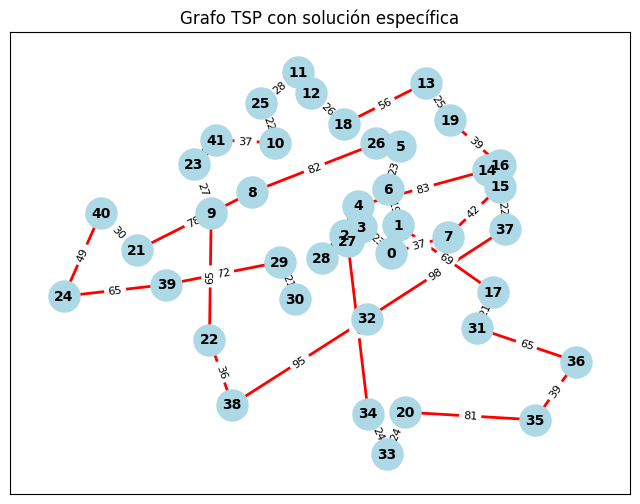

In [ ]:
def algoritmo_genetico(problema=problema,tamano_poblacion=100,mutacion=0.15,elitismo=0.1,generaciones=100):
    # problema = datos del problema
    # tamano_poblacion = Tamaño de la población
    # mutacion = probabilidad de una mutación
    # elitismo = porcion de la mejor poblacion a mantener
    # generaciones = nº de generaciones a generar para finalizar

    # Genera la poblacion inicial
    nodos = list(problema.get_nodes())
    poblacion = generar_poblacion(nodos,tamano_poblacion)

    # Inicializamos valores para la mejor solucion
    mejor_solucion, mejor_distancia = evaluar_poblacion(poblacion, problema)

    # Inciamos el cliclo de generaciones
    for i in range (generaciones):
        # Cruce de la poblacion(incluye mutación)
        poblacion = cruzar(poblacion, mutacion, problema)

        #Seleccionamos la población
        poblacion = seleccionar(problema, poblacion, tamano_poblacion, elitismo)

        #Evaluamos la nueva población
        (mejor_solucion, mejor_distancia) = evaluar_poblacion(poblacion, problema)

        print("Generacion #", i, "\nLa mejor solución es:" , mejor_solucion, "\ncon distancia " , mejor_distancia, "\n")

    return mejor_solucion, mejor_distancia


tamano_poblacion = 500
mutacion = 0.4
elitismo = 0.30
generaciones = 200

mejor_solucion, mejor_distancia = algoritmo_genetico(problema,tamano_poblacion,mutacion,elitismo,generaciones)

print(f"La mejor solución encontrada es: {mejor_solucion} con {generaciones} generaciones")
print(f"Distancia: {mejor_distancia}")

plot_tsp_solution(problema.edge_weights, mejor_solucion)